# In this notebook
I generate the NLCD principal component for training and test data.

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import rasterio
from rasterio.crs import CRS
from rasterstats import zonal_stats
from sklearn.decomposition import PCA
import osmnx as ox

In [ ]:
# This code draws a 500m buffer around each of the coordinates.
buffer_size = 500
coords = pd.read_csv('../data/stations.csv')
gdf = gpd.GeoDataFrame(coords, geometry=gpd.points_from_xy(coords.lon, coords.lat), crs="EPSG:4326")
gdf = gdf.to_crs(epsg=5070)
gdf['geometry'] = gdf.geometry.buffer(buffer_size)

In [10]:
gdf.head()

,stationId,lat,lon,geometry
0,KNCDURHA310,36.098000,-78.904000,"POLYGON ((1517656.261 1586545.921, 1517653.853..."
1,KNCCREED32,36.098000,-78.643000,"POLYGON ((1540562.125 1590744.109, 1540559.717..."
2,KNCCARY193,35.816000,-78.890000,"POLYGON ((1524539.957 1555701.796, 1524537.549..."
3,KNCRALEI392,35.801037,-78.681221,"POLYGON ((1543235.105 1557422.54, 1543232.698 ..."
4,KNCROUGE18,36.229704,-78.867091,"POLYGON ((1518251.311 1601647.028, 1518248.904..."


See above -- the geometry now contains a polygon around each coordinate, in the desired CRS. This will be helpful when we go to the next step, where we will calculate the percentage of each land-use class within each geometry.

In [7]:
# Path to your NLCD raster file
nlcd_paths = [
    "../data/nlcd/Annual_NLCD_LndCov_2019_CU_C1V0.tif",
    "../data/nlcd/Annual_NLCD_LndCov_2020_CU_C1V0.tif",
    "../data/nlcd/Annual_NLCD_LndCov_2021_CU_C1V0.tif",
    "../data/nlcd/Annual_NLCD_LndCov_2022_CU_C1V0.tif",
    "../data/nlcd/Annual_NLCD_LndCov_2023_CU_C1V0.tif",
    "../data/nlcd/Annual_NLCD_LndCov_2024_CU_C1V0.tif"
]

years = [2019, 2020, 2021, 2022, 2023, 2024]

all_results = []
for year, nlcd_path in zip(years, nlcd_paths):
    # Use zonal_stats to compute stats within each buffer
    stats = zonal_stats(
        vectors=gdf.geometry,
        raster=nlcd_path,
        stats="count",
        categorical=True,
        geojson_out=False,
        nodata=0.
    )

    # Convert to DataFrame
    stats_df = pd.DataFrame(stats)

    # Add ID back to results
    results = pd.concat([coords['stationId'], stats_df], axis=1)
    results.drop(columns='count', inplace=True)
    # Normalize to get percentage
    results_pct = results.set_index('stationId').div(results.set_index('stationId').sum(axis=1), axis=0) * 100

    # Add year to results
    results_pct['year'] = year
    results_pct.reset_index(inplace=True)
    all_results.append(results_pct)

In [12]:
all_results_df = pd.concat(all_results, ignore_index=True)
all_results_df.to_csv(f'../data/nlcd/class_by_station_{buffer_size}m_buffer.csv', index=False)
all_results_df.head()

,stationId,11,21,22,41,42,43,81,23,71,90,24,31,95,52,82,year
0,KNCDURHA310,0.344037,51.834862,19.151376,24.770642,1.376147,2.408257,0.114679,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019
1,KNCCREED32,0.572082,12.356979,14.187643,6.521739,8.123570,17.734554,33.524027,0.114416,2.059497,4.805492,NaN,NaN,NaN,NaN,NaN,2019
2,KNCCARY193,NaN,17.356322,17.471264,21.149425,1.724138,18.160920,NaN,23.448276,0.114943,NaN,0.574713,NaN,NaN,NaN,NaN,2019
3,KNCRALEI392,NaN,53.150057,36.998855,NaN,NaN,NaN,NaN,7.789233,NaN,NaN,2.061856,NaN,NaN,NaN,NaN,2019
4,KNCROUGE18,NaN,15.880322,1.150748,24.971231,12.428078,28.883774,16.685846,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019


The above cell shows the percentages for each NLCD class (with the given column names) for each station location. Eventually, we will want to fit our model over a grid of points. So we will calculate these same percentages over a grid of points.

I have a reference file for the coordinate system, which is based on a linear interpolation of ERA5-Land to a higher resolution.

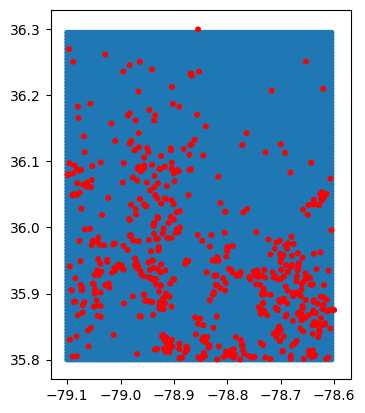

In [13]:
# Let's load the list of points
points = gpd.read_file('../data/ref_coords/era5_coords.shp')
points = points.to_crs(epsg=5070)
points['geometry'] = points.geometry.buffer(buffer_size)
points.to_crs('epsg:4326').plot()
gdf.to_crs('epsg:4326').plot(ax=plt.gca(), color='red', markersize=5)
plt.show()

In [13]:
# Path to your NLCD raster file
nlcd_paths = [
    "../data/nlcd/Annual_NLCD_LndCov_2019_CU_C1V0.tif",
    "../data/nlcd/Annual_NLCD_LndCov_2020_CU_C1V0.tif",
    "../data/nlcd/Annual_NLCD_LndCov_2021_CU_C1V0.tif",
    "../data/nlcd/Annual_NLCD_LndCov_2022_CU_C1V0.tif",
    "../data/nlcd/Annual_NLCD_LndCov_2023_CU_C1V0.tif",
    "../data/nlcd/Annual_NLCD_LndCov_2024_CU_C1V0.tif",
]

years = [2019, 2020, 2021, 2022, 2023, 2024]
# years = [2023]
all_results = []
for year, nlcd_path in zip(years, nlcd_paths):
    # Use zonal_stats to compute stats within each buffer
    stats = zonal_stats(
        vectors=points.geometry,
        raster=nlcd_path,
        stats="count",
        categorical=True,
        geojson_out=False,
        nodata=0.
    )

    # Convert to DataFrame
    stats_df = pd.DataFrame(stats)
    
    # Add ID back to results
    # results = pd.concat([points_gdf['lat'], points_gdf[''] stats_df], axis=1)
    # stats_df.drop(columns='count', inplace=True)
    # Normalize to get percentage
    stats_df.drop(columns='count', inplace=True)
    results_pct = stats_df.div(stats_df.sum(axis=1), axis=0) * 100

    # Add year to results
    results_pct['year'] = year
    results_pct['lon'] = points['lon']
    results_pct['lat'] = points['lat']
    results_pct.reset_index(inplace=True)
    all_results.append(results_pct)
    print(f"Done with {year} stats")

Done with 2019 stats
Done with 2020 stats
Done with 2021 stats
Done with 2022 stats
Done with 2023 stats
Done with 2024 stats


In [14]:
all_results = pd.concat(all_results, ignore_index=True)
all_results.drop(columns=['index'], inplace=True)
all_results.to_csv(f'../data/nlcd/class_by_grid_{buffer_size}m_buffer.csv', index=False)

# Now, let's compare the two
We now have the class by station, and the class by grid.

In [14]:
train = pd.read_csv(f'../data/nlcd/class_by_station_{buffer_size}m_buffer.csv')
test = pd.read_csv(f'../data/nlcd/class_by_grid_{buffer_size}m_buffer.csv')

In [15]:
# We will fill NA values with a very small number.
X = train.drop(columns=['stationId', 'year']).fillna(1e-6)
X_test = test.drop(columns=['year']).fillna(1e-6)

In [16]:
# This transform is a good way to handle percentage based features.
def clr(X):
    """Centered log-ratio transformation."""
    X = np.asarray(X)
    log_X = np.log(X)              # assumes no zero values!
    gm = np.mean(log_X, axis=1)    # geometric mean (in log-space)
    return log_X - gm[:, np.newaxis]

# Example
X_clr = clr(X.values)

In [21]:
classes = train.columns[1:-1]

Text(10, 0.96, '95% Variance')

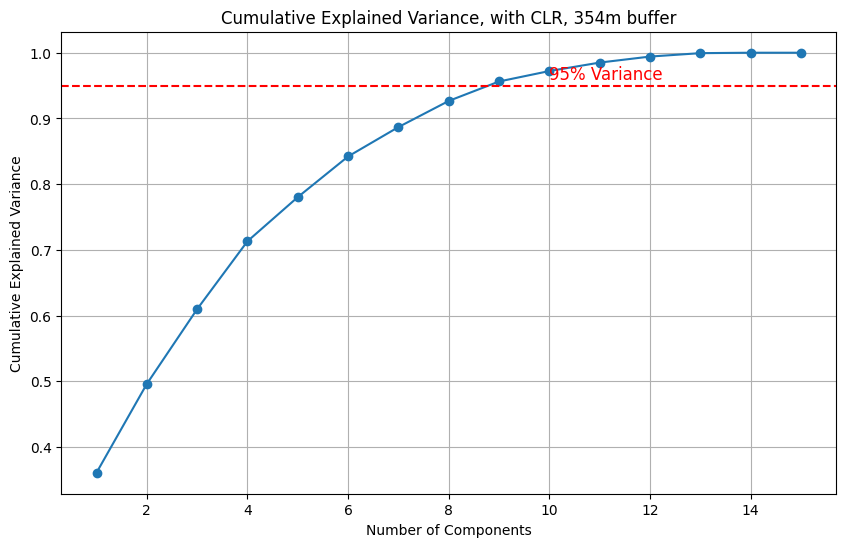

In [22]:
pca = PCA(n_components=len(classes))

pca.fit(X_clr)

X_train_pca = pca.transform(X_clr)

# Visualize the cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, 16), np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title('Cumulative Explained Variance, with CLR, 354m buffer')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.axhline(y=0.95, color='r', linestyle='--')
plt.text(10, 0.96, '95% Variance', color='red', fontsize=12)

In [23]:

# year_2023.drop(columns=['year'], inplace=True)

X_test = test[X.columns]

X_test.fillna(1e-6, inplace=True)

X_test_clr = clr(X_test.values)
X_test_pca = pca.transform(X_test_clr)

/var/folders/3r/mm1k6hx10zlgnb46j7vtvxz80000gq/T/ipykernel_13539/985316439.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.fillna(1e-6, inplace=True)


In [25]:
train_df = np.concatenate([train[['stationId', 'year']], X_train_pca[:, :2]], axis=1)

# Convert to pandas DataFrame
train_df = pd.DataFrame(train_df, columns=['stationId', 'year', 'PC1', 'PC2'])

# Save to CSV
train_df.to_csv(f'../data/nlcd/pca_train_{buffer_size}m_buffer.csv', index=False)

In [26]:
test_df = np.concatenate([test[['year', 'lon', 'lat']], X_test_pca[:, :2]], axis=1)

In [27]:
test_df = pd.DataFrame(test_df, columns=['year', 'lon', 'lat', 'PC1', 'PC2'])
test_df = gpd.GeoDataFrame(test_df, geometry=gpd.points_from_xy(test_df['lon'], test_df['lat']), crs="EPSG:4326")

In [29]:
# test_df['lon'] = test_df.geometry.x
# test_df['lat'] = test_df.geometry.y
# Save to CSV
# test_df.drop(columns='geometry', inplace=True)
test_df.to_csv(f'../data/nlcd/pca_test_{buffer_size}m_buffer.csv', index=False)

# Lastly, let's make an informative figure
We want to be able to explain the buffer size approach graphically, so it's easy to understand the general approach.

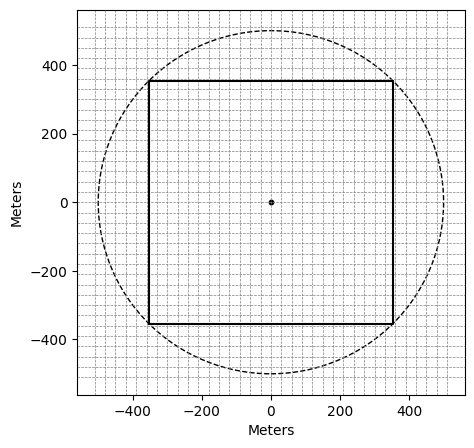

In [30]:
# Create a grid of lines, and plot on matplotlib
x = np.arange(-510, 510+1, 30)
y = np.arange(-510, 510+1, 30)


plt.figure(figsize=(5, 5))
for i in x:
    plt.axvline(i, color='grey', linestyle='--', linewidth=0.5)
for i in y:
    plt.axhline(i, color='grey', linestyle='--', linewidth=0.5)

# Draw a circle centered at (0, 0) with radius 250
circle = plt.Circle((0, 0), 500, color='black', fill=False, linestyle='--')
plt.gca().add_artist(circle)

# Add a point in the middle
plt.scatter(0, 0, color='black', s=10, label='Station Location')

# Draw a box around the circle
l = 707/2
plt.plot([-l, l, l, -l, -l], [-l, -l, l, l, -l], color='black', linestyle='-')
plt.ylabel("Meters")
plt.xlabel("Meters")
plt.show()

# One final figure
Let's visualize the principal components along with the station locations for reference.

We will add in the highways for a visual reference.

In [ ]:
# Let's load the highways.

# Define your area of interest
place = "Durham, North Carolina, USA"  # or use a bounding box
west, south, east, north = -79.1, 35.8, -78.6, 36.3
G = ox.graph_from_bbox([west, south, east, north], network_type='drive', custom_filter='["highway"~"motorway|trunk"]')
edges = ox.graph_to_gdfs(G, nodes=False, edges=True)

# Reference coords
coords = pd.read_csv('../data/stations.csv')

# Load the gridded PC
buffer_size = 500
test = pd.read_csv(f'../data/nlcd/pca_test_{buffer_size}m_buffer.csv')

# Select just the data for one year
year = 2023
year_2023 = test[test['year'] == year]
lat = year_2023['lat']
lon = year_2023['lon']
mask = test['year'] == year
X_test_pca = year_2023['PC1'].values.reshape(-1, 1)

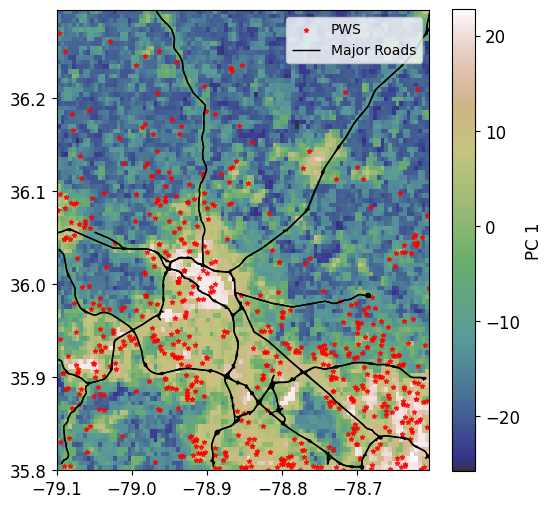

In [37]:
# Make the actual figure.
plt.figure(figsize=(6, 6))

# Show the Principal Component
plt.imshow(X_test_pca.reshape(100, 100).T, extent=(lon.min(), lon.max(), lat.min(), lat.max()), origin='lower', cmap='gist_earth', alpha=0.8)
cbar = plt.colorbar()#label='PC 1', size=15)#, ticklabelsize=12)
cbar.ax.tick_params(axis='y', labelsize=12)
cbar.set_label(label="PC 1", size=12)

# Plot the coordinates
plt.scatter(coords['lon'], coords['lat'], marker='*', color='red', alpha=0.8, s=10, label='PWS')

# Plot the highways
edges.plot(ax=plt.gca(), color='black', linewidth=1, label='Major Roads')

# Set the limits on the extent of the map.
plt.xlim(year_2023['lon'].min(), year_2023['lon'].max())
plt.ylim(year_2023['lat'].min(), year_2023['lat'].max())

# Add the legend
plt.legend(loc='upper right')

# Adjust the fontsize
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Save figure
# plt.savefig(f'../figures/pca_component_1_{year}.pdf', dpi=1000)#, bbox_inches='tight')
plt.show()